In [72]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
import sys
sys.path.append('../helpers')

import seaborn as sns

In [73]:
# Открываем файл и указываем путь к дереву
file_event = uproot.open("../output/data/mc_reco_event.root")
tree_event = file_event["eRecoTree"]

file_pulse = uproot.open("../output/data/mc_reco_pulse.root")
tree_pulse = file_pulse["pRecoTree"]

# Читаем все ветки в Pandas DataFrame
df_event = tree_event.arrays(library="pd")
df_pulse = tree_pulse.arrays(library="pd")

In [74]:
df_event.describe()

,eventId,number,clusterID,nRespMuons,nTrueMuons,eventWeight,trueTime,trueFirstMuonEnergy,trueFirstMuonTheta,trueFirstMuonPhi,...,truePrimaryPhi,truePrimaryEnergy,trueBundleEnergy,RecoTheta,RecoPhi,RecoRefTime,RecoNHits,RecoNStrings,RecoDEDX,RecoZDist
count,7.477000e+04,74770.000000,74770.0,74770.000000,74770.000000,74770.0,74770.000000,74770.000000,74770.000000,74770.000000,...,74770.000000,74770.000000,74770.000000,74770.000000,74770.000000,74770.000000,74770.000000,74770.00000,74770.000000,74770.000000
mean,1.498717e+07,37436.444483,1.0,14.939053,23.193366,1.0,1882.776245,501.134308,146.172089,180.788498,...,180.788498,882.887207,13457.478516,149.344894,183.170303,1832.873047,10.538893,3.18153,0.848295,238.261765
std,8.648682e+06,21613.511493,0.0,21.123195,20.866363,0.0,220.205200,2164.348389,17.833578,104.708336,...,104.708336,3283.854980,23349.595703,19.770779,105.440765,283.176727,3.958966,0.90628,21.752007,109.694824
min,8.050000e+02,2.000000,1.0,1.000000,0.000000,1.0,865.370728,-100.331055,94.667320,0.000641,...,0.000641,0.389298,80.138680,2.736465,0.000950,-50.237698,7.000000,1.00000,0.000000,2.042186
25%,7.540475e+06,18719.250000,1.0,5.000000,8.000000,1.0,1704.009552,43.321991,132.596745,90.477737,...,90.477737,93.049313,3348.394531,137.804317,95.632969,1649.961517,8.000000,3.00000,0.000000,154.118572
50%,1.497529e+07,37436.500000,1.0,9.000000,17.000000,1.0,1897.132385,158.133369,146.562263,181.370720,...,181.370720,296.499908,7335.693115,152.572632,182.669403,1819.572815,9.000000,3.00000,0.000000,210.362061
75%,2.251513e+07,56153.750000,1.0,17.000000,32.000000,1.0,2066.182983,437.450630,160.607639,272.229843,...,272.229843,763.725204,14805.449463,164.650986,276.725357,2011.824707,12.000000,4.00000,0.000000,304.277885
max,3.005496e+07,74871.000000,1.0,404.000000,99.000000,1.0,2340.984131,399952.750000,179.766769,359.982361,...,359.982361,228002.828125,584683.312500,180.000000,360.000000,3938.582764,89.000000,7.00000,2000.000000,540.187561


In [75]:
df_pulse.describe()

,eventId,number,chanID,pulseLY,pulseTime,dTime,dTimeExpVsRec,pulseZ,RecoDistToPoint_BH,ExpectedOMTime,trueFirstMuonDistToPoint_BH
count,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06,5.632775e+06
mean,1.499827e+07,3.735629e+04,2.313064e+02,1.808921e+00,1.883594e+03,2.307289e+01,1.435721e+02,5.502322e+01,9.984243e+01,1.666450e+02,1.019389e+02
std,8.649601e+06,2.161169e+04,2.837492e+02,1.772436e+01,1.329483e+03,1.326701e+03,1.381208e+03,1.498569e+02,8.289010e+01,6.146234e+02,8.109798e+01
min,8.050000e+02,2.000000e+00,0.000000e+00,1.117587e-08,-1.534786e+03,-4.113951e+03,-4.196023e+03,-2.644021e+02,2.735364e-04,-1.404149e+03,2.041582e-03
25%,7.562127e+06,1.863100e+04,7.000000e+01,6.550475e-01,9.769016e+02,-9.000747e+02,-6.944150e+02,-5.259414e+01,3.903665e+01,-3.064426e+02,4.255761e+01
50%,1.498905e+07,3.729700e+04,1.850000e+02,9.490004e-01,1.845760e+03,-1.817993e+00,3.892334e+00,8.250183e+01,7.710405e+01,1.061971e+02,8.169536e+01
75%,2.254018e+07,5.605900e+04,2.550000e+02,1.284571e+00,2.856217e+03,9.692067e+02,1.054374e+03,1.874048e+02,1.315501e+02,5.893931e+02,1.377554e+02
max,3.005496e+07,7.487100e+04,2.015000e+03,1.339245e+04,5.735318e+03,4.259678e+03,5.714396e+03,2.678679e+02,8.316808e+02,3.107615e+03,7.772384e+02


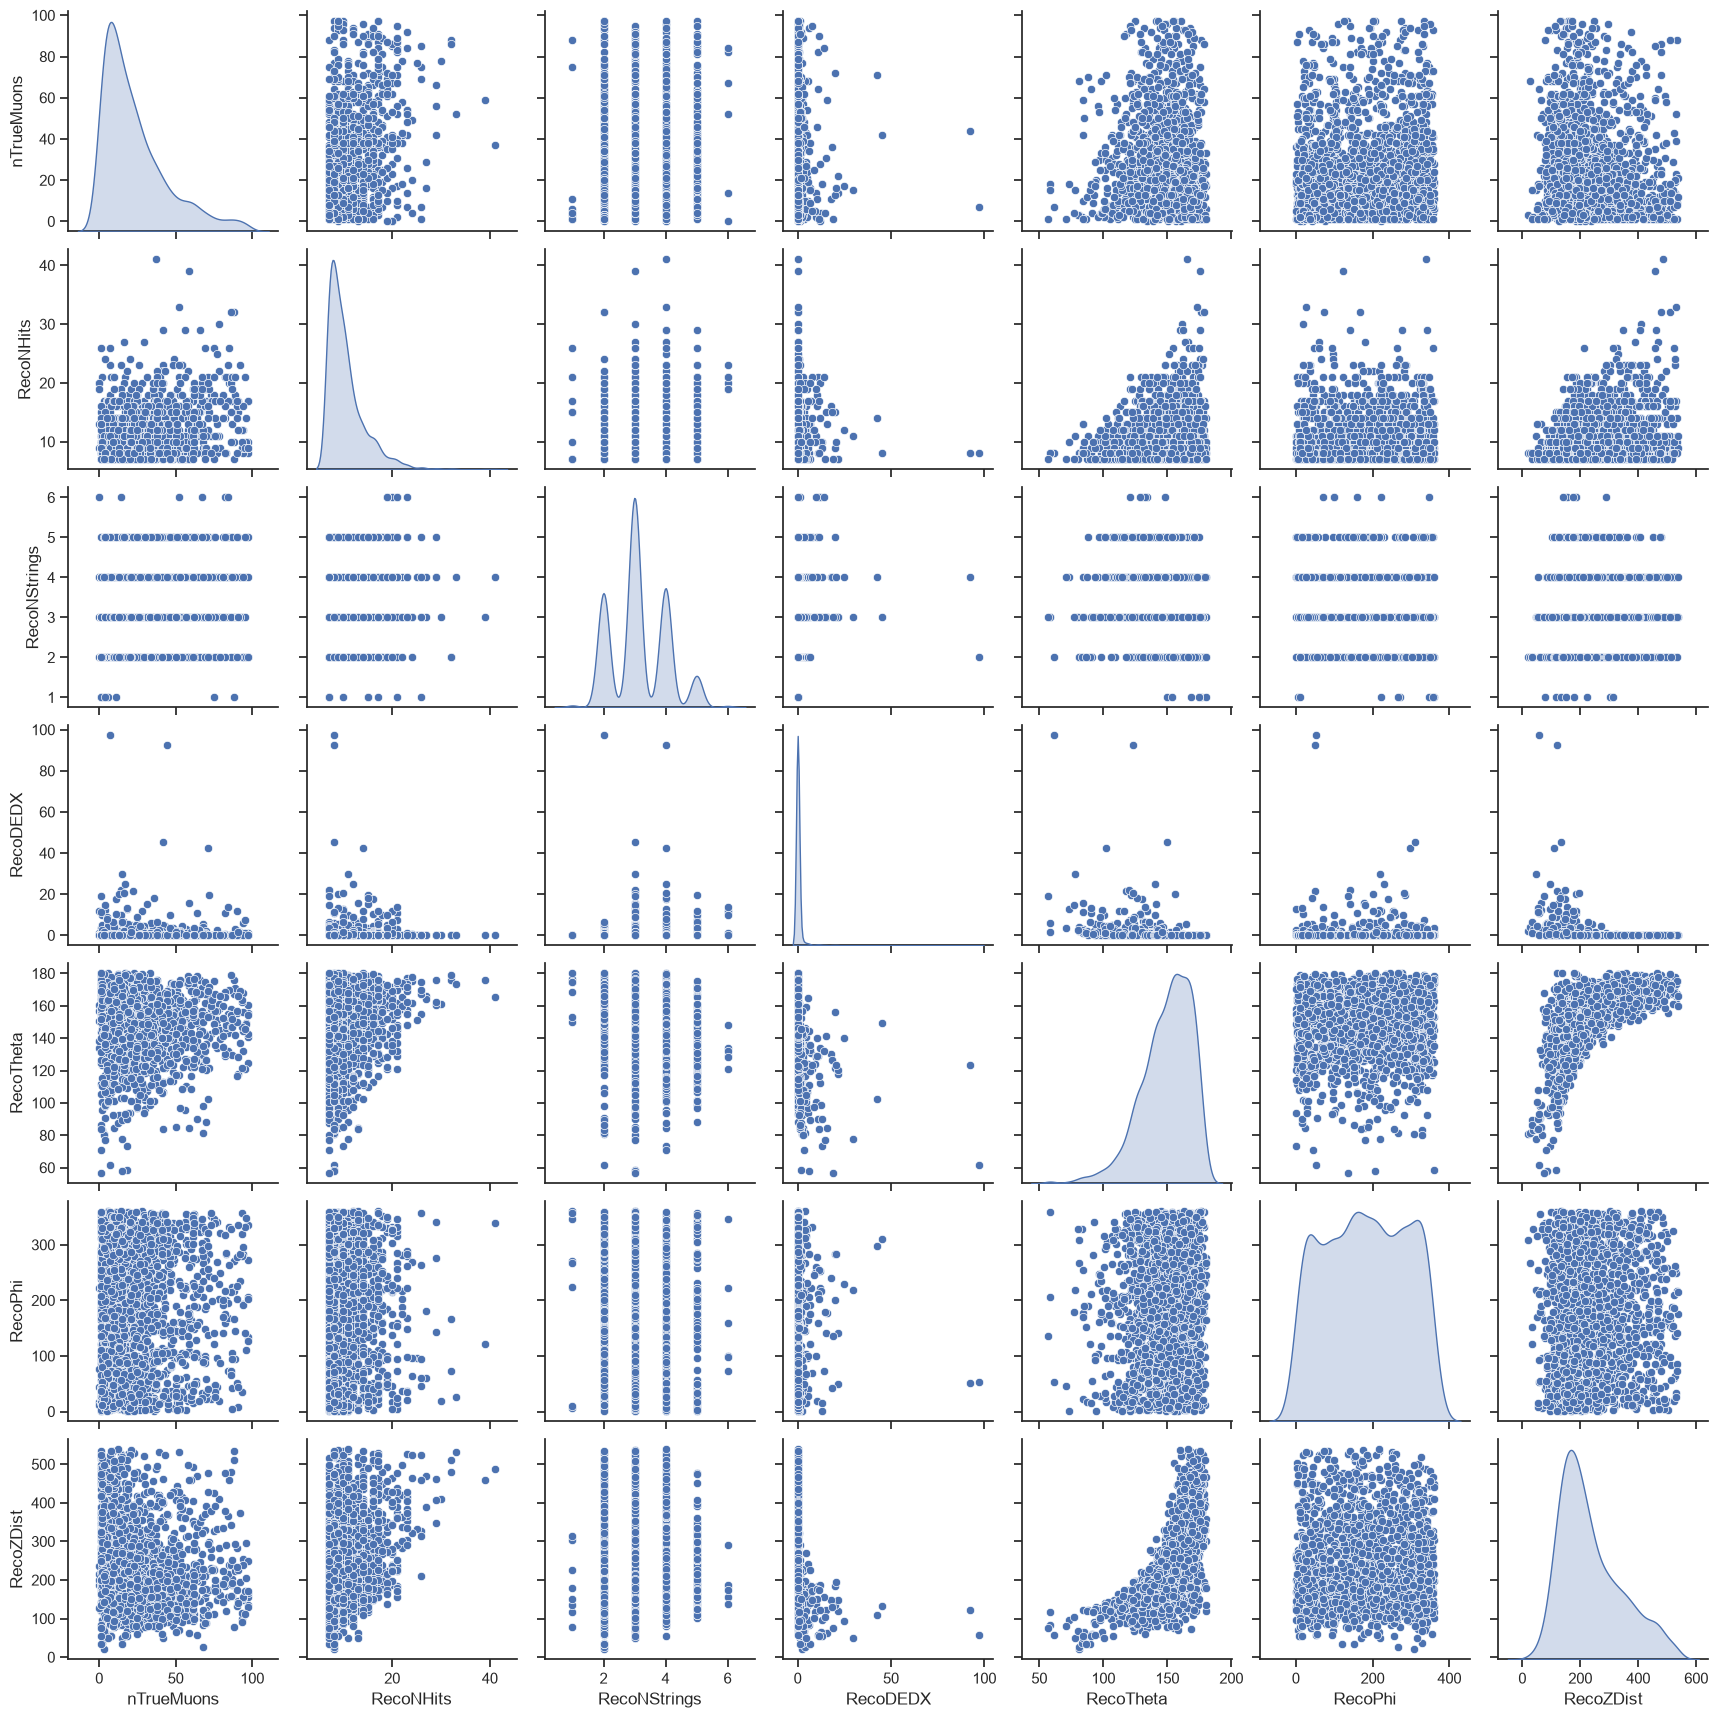

In [76]:
# sns.set_theme(style="ticks")
# sns.pairplot(df_event.iloc[:][["nTrueMuons", "RecoNHits", "RecoNStrings", "RecoDEDX", "RecoTheta", "RecoPhi"]], diag_kind="kde", corner=False)

sns.set_theme(style="ticks")

# Выбираем нужные колонки
data_subset = df_event.iloc[:2000][["nTrueMuons", "RecoNHits", "RecoNStrings", "RecoDEDX", "RecoTheta", "RecoPhi", "RecoZDist"]]

g = sns.pairplot(
    data_subset,
    # kind="hist",            # Меняем точки на цветовую плотность!
    diag_kind="kde",       # На диагонали оставляем одномерную плотность
    corner=False,
    # plot_kws={
    #     # "fill": True,      # Заливать контуры цветом
    #     # "thresh": 0,       # Показывать даже зоны с низкой плотностью
    #     # "levels": 100,     # Плавность цветовых переходов (чем больше, тем плавнее)
    #     "cmap": "RdBu_r"     # Цветовая палитра: от белого к насыщенному красному
    # },
    # diag_kws={'color': "Red", 'fill': True},
)

plt.show()

              nTrueMuons  RecoNHits  RecoNStrings  RecoDEDX  RecoTheta  \
nTrueMuons      1.000000   0.434619      0.240154  0.027968  -0.125367   
RecoNHits       0.434619   1.000000      0.267960 -0.002479   0.173206   
RecoNStrings    0.240154   0.267960      1.000000  0.005588  -0.351156   
RecoDEDX        0.027968  -0.002479      0.005588  1.000000  -0.074041   
RecoTheta      -0.125367   0.173206     -0.351156 -0.074041   1.000000   
RecoPhi        -0.019500   0.004671      0.031165 -0.004618  -0.008967   
RecoZDist      -0.138864   0.324786     -0.105510 -0.042569   0.676252   

               RecoPhi  RecoZDist  
nTrueMuons   -0.019500  -0.138864  
RecoNHits     0.004671   0.324786  
RecoNStrings  0.031165  -0.105510  
RecoDEDX     -0.004618  -0.042569  
RecoTheta    -0.008967   0.676252  
RecoPhi       1.000000   0.022501  
RecoZDist     0.022501   1.000000  


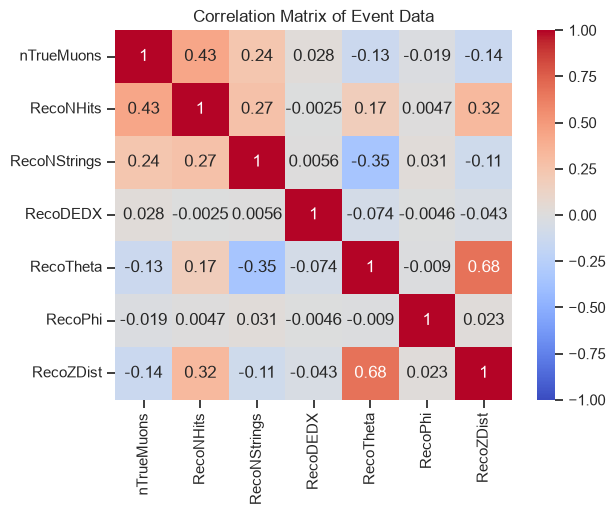

In [77]:
corr_matrix = df_event.iloc[:][["nTrueMuons", "RecoNHits", "RecoNStrings", "RecoDEDX", "RecoTheta", "RecoPhi", "RecoZDist"]].corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Event Data')
plt.show()

In [78]:
df_merged = df_pulse.merge(df_event, how = "left", on = "eventId")
df_merged.head()

,eventId,number_x,chanID,pulseLY,pulseTime,dTime,dTimeExpVsRec,pulseZ,RecoDistToPoint_BH,ExpectedOMTime,...,truePrimaryPhi,truePrimaryEnergy,trueBundleEnergy,RecoTheta,RecoPhi,RecoRefTime,RecoNHits,RecoNStrings,RecoDEDX,RecoZDist
0,21060,2,11,1.392168,176.627228,-1436.860718,1913.027100,-97.595131,41.204659,476.166443,...,244.340454,814.695312,18113.259766,178.640610,45.199497,1613.487915,12.0,3.0,0.0,180.228241
1,21060,2,11,1.392168,176.627228,-1436.860718,1913.027100,-97.595131,41.204659,476.166443,...,303.845581,814.695312,17335.949219,166.787354,323.516968,1586.738403,14.0,2.0,0.0,199.880112
2,21060,2,19,0.525723,1114.821411,-498.666504,573.261780,22.398867,40.747845,74.595276,...,244.340454,814.695312,18113.259766,178.640610,45.199497,1613.487915,12.0,3.0,0.0,180.228241
3,21060,2,19,0.525723,1114.821411,-498.666504,573.261780,22.398867,40.747845,74.595276,...,303.845581,814.695312,17335.949219,166.787354,323.516968,1586.738403,14.0,2.0,0.0,199.880112
4,21060,2,19,0.936995,2039.731934,426.244019,-351.648743,22.398867,40.747845,74.595276,...,244.340454,814.695312,18113.259766,178.640610,45.199497,1613.487915,12.0,3.0,0.0,180.228241


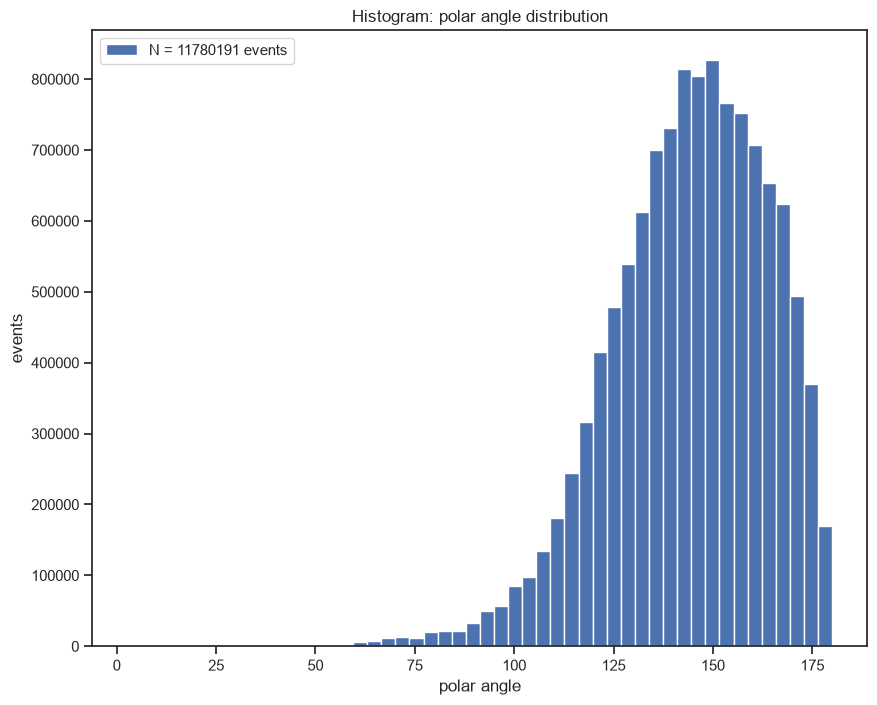

In [85]:
fig, ax = plt.subplots(figsize=(10, 8))
n_events = len(df_merged)
ax.hist(df_merged['RecoTheta'], bins=50, label=f'N = {n_events} events')

ax.set_xlabel('polar angle')
ax.set_ylabel('events')
ax.set_title('Histogram: polar angle distribution')
ax.legend()
plt.show()

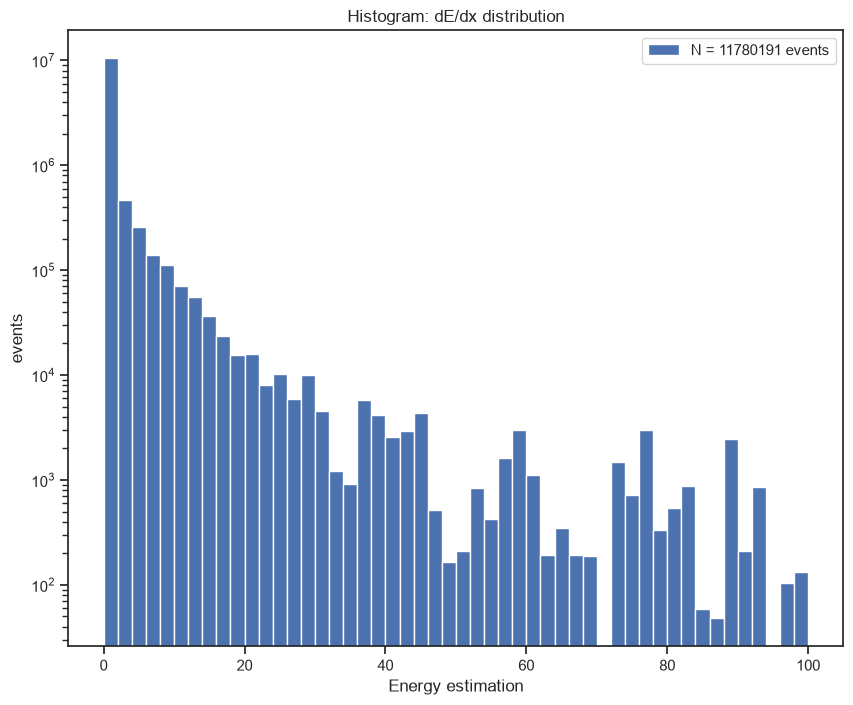

In [86]:
fig, ax = plt.subplots(figsize=(10, 8))
n_events = len(df_merged)
ax.hist(df_merged['RecoDEDX'], bins=50, range=(0, 100), label=f'N = {n_events} events')

ax.set_xlabel('Energy estimation')
ax.set_ylabel('events')
ax.set_yscale('log')
ax.set_title('Histogram: dE/dx distribution')
ax.legend()
plt.show()

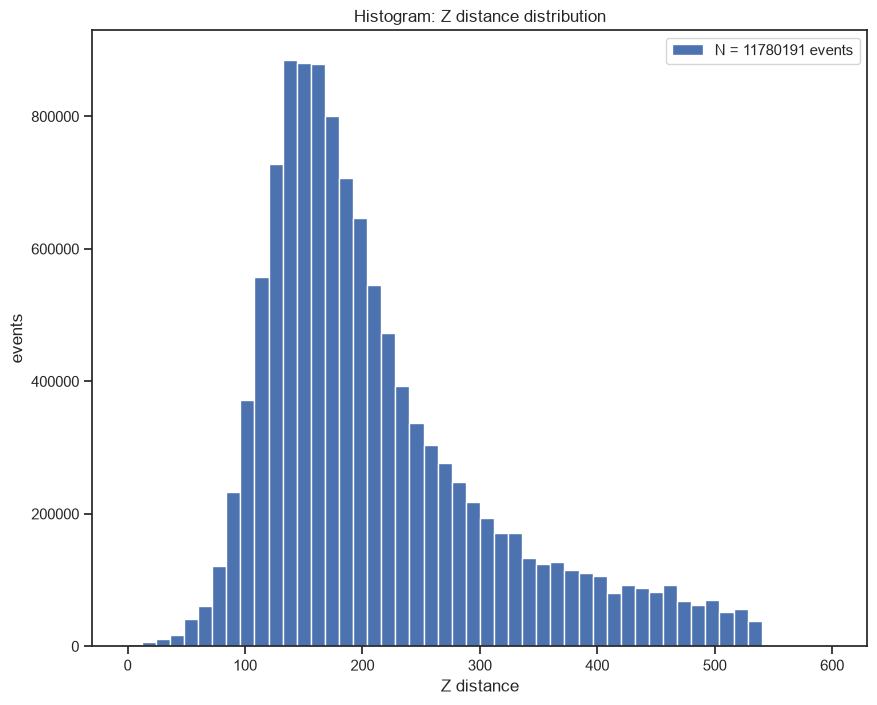

In [91]:
fig, ax = plt.subplots(figsize=(10, 8))
n_events = len(df_merged)
ax.hist(df_merged['RecoZDist'], bins=50, range=(0, 600), label=f'N = {n_events} events')

ax.set_xlabel('Z distance')
ax.set_ylabel('events')
# ax.set_yscale('log')
ax.set_title('Histogram: Z distance distribution')
ax.legend()
plt.show()

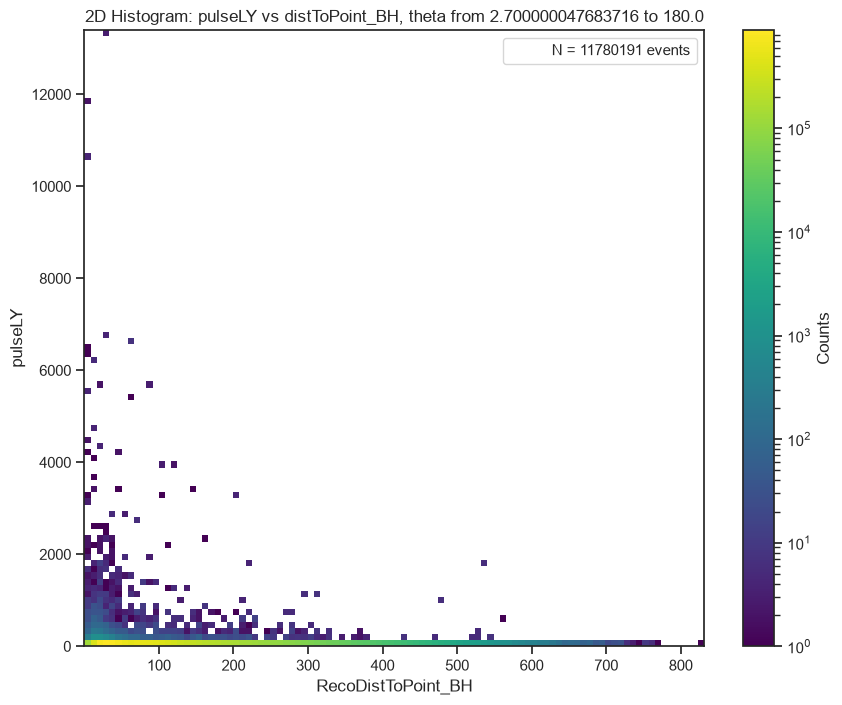

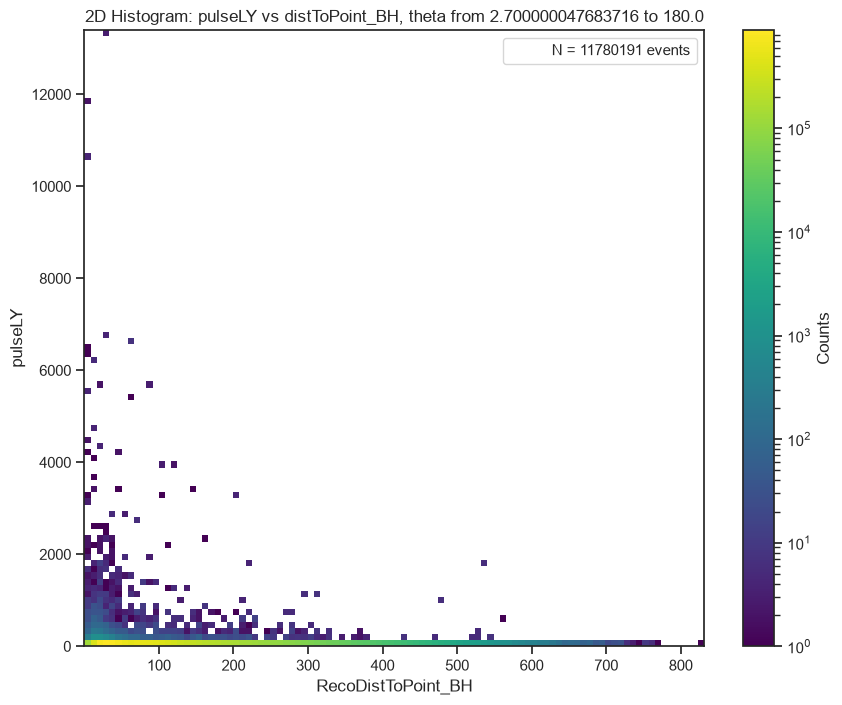

In [71]:
import analysis_help as ah
ah.LY_vs_dist_ploter(df_merged)